In [1]:
import cooltools, cooler
# import cooltools.lib.plotting
import numpy as np
import scipy as sp
import hicstraw
import os
import pandas as pd
import matplotlib.pyplot as plt
# plt.ion()

from matplotlib import colormaps as cm
from matplotlib.colors import LogNorm, ListedColormap
import itertools
import tqdm
from sklearn.cluster import AgglomerativeClustering

## 0. Necessary data

In [2]:
## Telomeres

## uncomment these for raw abundance of CCTAA motifs:
# dir_telomere_motif="/workdir/tx84/Research/2024_LepChromosomes/00.assembly/Papilio_bianor/02.hifiasm.no_mito.D10.k63.w51.max-kocc.1000.hg-size.520m.v0_20_0.s.0_5/scaffold.p_ctg.no_circ/05.yahs/out_JBAT.review_02.FINAL.motifs"
# df_telo_plus=pd.read_csv(dir_telomere_motif+"/coverage.motif_CCTAA_2copies.merged.strand_plus.w100s100.bed",sep='\t',header=None)
# df_telo_minus=pd.read_csv(dir_telomere_motif+"/coverage.motif_CCTAA_2copies.merged.strand_minus.w100s100.bed",sep='\t',header=None)

## I chose to use a binary summaries of found telomeres

dir_telo="/workdir/tx84/Research/2024_LepChromosomes/00.assembly/Papilio_bianor/04.0.final_assembly/telomeres.final_assembly"
df_telo_terminus=pd.read_csv(dir_telo+"/telomere_found.txt",sep='\t',header=None)

## Repeats
dir_repeats="/workdir/tx84/Research/2024_LepChromosomes/00.assembly/Papilio_bianor/05.8.1.satellite.earlgrey.r1.manual_curation/3.1.annotate.curated_lib/Papilio_bianor_summaryFiles"

df_srp_sat=pd.read_csv(dir_repeats+"/Papilio_bianor.filteredRepeats.Satellite.coverage_w50ks50k.bed",sep='\t',header=None)
df_te=pd.read_csv(dir_repeats+"/Papilio_bianor.filteredRepeats.TE.coverage_w50ks50k.bed",sep='\t',header=None)

## 100N gaps

dir_gaps="/workdir/tx84/Research/2024_LepChromosomes/00.assembly/Papilio_bianor/04.0.final_assembly/gaps.final_assembly"
df_gap=pd.read_csv(dir_gaps+"/match.motif.100N.bed",sep='\t',header=None)

## GC content
dir_gcc="/workdir/tx84/Research/2024_LepChromosomes/00.assembly/Papilio_bianor/04.0.final_assembly/gc_content.final_assembly"

df_gcc=pd.read_csv(dir_gcc+"/gc_content.final_assembly.w50000s50000.bed",sep='\t',header=None)


In [3]:
## major TE block boundaries measured in Mb

chromList1=np.array([1,2,4,5,6,7,8,9,10,11,12,13]) # has TE block
chromList2=np.array([3,14]) # has TE block
chromList3=np.arange(15,31,1)

dict_TE_block = {}
dict_TE_block["chr1,5"]=8325/1e3
dict_TE_block["chr1,3"]=10875/1e3
dict_TE_block["chr2,5"]=5682/1e3
dict_TE_block["chr2,3"]=13675/1e3
dict_TE_block["chr3,5"]=0/1e3
dict_TE_block["chr3,3"]=5154/1e3
dict_TE_block["chr4,5"]=5330/1e3
dict_TE_block["chr4,3"]=9164/1e3
dict_TE_block["chr5,5"]=5400/1e3
dict_TE_block["chr5,3"]=7574/1e3
dict_TE_block["chr6,5"]=2425/1e3
dict_TE_block["chr6,3"]=6825/1e3
dict_TE_block["chr7,5"]=3730/1e3
dict_TE_block["chr7,3"]=6330/1e3
dict_TE_block["chr8,5"]=4280/1e3
dict_TE_block["chr8,3"]=8004/1e3
dict_TE_block["chr9,5"]=4762/1e3
dict_TE_block["chr9,3"]=10438/1e3
dict_TE_block["chr10,5"]=3745/1e3
dict_TE_block["chr10,3"]=6275/1e3
dict_TE_block["chr11,5"]=2352/1e3
dict_TE_block["chr11,3"]=5455/1e3
dict_TE_block["chr12,5"]=1704/1e3
dict_TE_block["chr12,3"]=2715/1e3
dict_TE_block["chr13,5"]=3773/1e3
dict_TE_block["chr13,3"]=5175/1e3
dict_TE_block["chr14,5"]=11560/1e3
dict_TE_block["chr14,3"]=20850/1e3

## 1. Convert .hic to .cool or .mcool formats

In [260]:
os.chdir("/workdir/tx84/Research/2024_LepChromosomes/00.assembly/Papilio_bianor/06.0.hic_final_assembly.juicer/aligned")


In [18]:
hic_file = 'inter_30.hic'
multires_cool_file = 'inter_30.multires.VC_SQRT.mcool'
hic = hicstraw.HiCFile(hic_file)
resolutions = hic.getResolutions()
print(resolutions)

data_type = 'observed' # (previous default / "main" data) or 'oe' (observed/expected)
normalization = "VC_SQRT"  # NONE, VC, VC_SQRT, KR, SCALE, etc.
genomeID = 'Papilio_bianor'

chrom_sizes = pd.Series({chrom.name: chrom.length for chrom in hic.getChromosomes() if chrom.name != "All"})


[2500000, 1000000, 500000, 250000, 100000, 50000, 25000, 10000, 5000, 1000]


In [19]:
# First write the chromosome sizes:
with open(genomeID + '.size', 'w') as fsize:
    for chrom in hic.getChromosomes():
        if chrom.name != "All":
            fsize.write(f"{chrom.name}\t{chrom.length}\n")
     

In [20]:
# Then write the counts in text file:

for res in resolutions:
    print(res)
    with open(multires_cool_file.replace('.mcool', "." + str(res) + ".txt"), 'w') as fo:
        for i in np.arange(0,30,1):
            for j in np.arange(i,30,1):
                chrom1 = chrom_sizes.index[i]
                chrom2 = chrom_sizes.index[j]
                result = hicstraw.straw(data_type, normalization, hic_file, chrom1, chrom2, 'BP', res)
                for k in range(len(result)):
                    start1 = result[k].binX
                    start2 = result[k].binY
                    value = result[k].counts
                    fo.write(f"{chrom1}\t{start1}\t{start1}\t{chrom2}\t{start2}\t{start2}\t{value}\n")

2500000
1000000
500000
250000
100000
50000
25000
10000
5000
1000


In [ ]:
for res in resolutions:
    
    print(res)

    # # for int dtype:
    # os.system(f"~/miniconda3/envs/EnvPy3.12/bin/cooler load --append -f bg2 {genomeID}.size:{res} {multires_cool_file.replace('.mcool', '.' + str(res) + '.txt')} {multires_cool_file}::resolutions/{res}")

    # for float dtype:
    os.system(f"~/miniconda3/envs/EnvPy3.12/bin/cooler load --count-as-float --append -f bg2 {genomeID}.size:{res} {multires_cool_file.replace('.mcool', '.' + str(res) + '.txt')} {multires_cool_file}::resolutions/{res}")

print('finished!')

## don't forget to "cooler balance ..." coolers in the multiresolution mcool file if it stores the raw observed counts!



## 2. Analyzing Hi-C data

In [4]:
os.chdir("/workdir/tx84/Research/2024_LepChromosomes/00.assembly/Papilio_bianor/06.0.hic_final_assembly.juicer.adult_F/aligned")


In [5]:
mcool_file = 'inter_30.multires.mcool'

In [6]:
cooler.fileops.list_coolers(f'{mcool_file}')

['/resolutions/1000',
 '/resolutions/5000',
 '/resolutions/10000',
 '/resolutions/25000',
 '/resolutions/50000',
 '/resolutions/100000',
 '/resolutions/250000',
 '/resolutions/500000',
 '/resolutions/1000000',
 '/resolutions/2500000']

In [7]:
def get_chrom_size(clr,scaffold_name):

    return clr.chromsizes[scaffold_name]/1e6

def get_contact_matrix_per_chrom(clr,chrom):

    return clr.matrix(balance=True)[chromstarts[chrom-1]:chromends[chrom-1],chromstarts[chrom-1]:chromends[chrom-1]]

def map_interval_to_pixels(clr,scaffold_name,left_bp,right_bp):

    dx = clr.binsize
    pixels = np.arange(clr.extent(scaffold_name)[0],clr.extent(scaffold_name)[1])
    pixel_leftpoint_coordinates = (pixels - clr.extent(scaffold_name)[0] + 0.0) * clr.binsize
    
    return pixels[np.logical_and((pixel_leftpoint_coordinates >= left_bp),(pixel_leftpoint_coordinates < right_bp))]

def get_striped_mean(A):

    idx_nan = np.where(np.isnan(np.diagonal(A)))[0]
    idx_not_nan = np.where(np.logical_not(np.isnan(np.diagonal(A))))[0]
    
    L = A.shape[0]
    ΔL = np.arange(0,L)
    
    A_diag_mean = []
    for δL in ΔL: 
        A_diag = np.diagonal(A,offset=δL)
        A_diag = A_diag[np.logical_not(np.isnan(A_diag))]
        if A_diag.shape[0] > 0:
            A_diag_mean.append(A_diag.mean())
        else:
            A_diag_mean.append(np.nan)

    return A_diag_mean

def drop_nan_from_end(P):

    last_non_nan_index = np.where(~np.isnan(P))[0][-1]

    return P[:last_non_nan_index + 1]

def log_smoothing(Ps,s,log_grid_points_number):

    log_s = []
    log_P = []
    grids = np.logspace(3,7,base=10,num=log_grid_points_number) # 1e3 to 1e7 binning

    for i in np.arange(0,grids.shape[0]-1):
        idx = np.logical_and(s>=grids[i],s<grids[i+1]) 
        log_s.append((np.log10(s[idx])).mean())
        log_P.append((np.log10(Ps[idx])).mean())

    return log_s,log_P

### 2.1. Plotting a global view of Hi-C and assembly results

In [8]:
clr = cooler.Cooler(f'{mcool_file}::resolutions/250000')

### to print chromosomes and binsize for this cooler
# print(f'chromosomes: {clr.chromnames}, binsize: {clr.binsize}')

### to make a list of chromosome start/ends in bins:
chromstarts = []
chromends = []
for i in clr.chromnames:
    # print(f'{i} : {clr.extent(i)}')
    chromstarts.append(clr.extent(i)[0])
    chromends.append(clr.extent(i)[1])

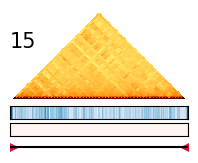

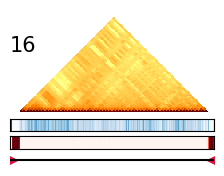

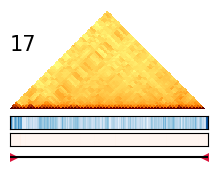

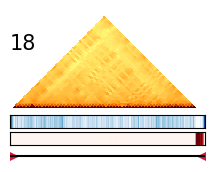

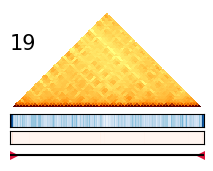

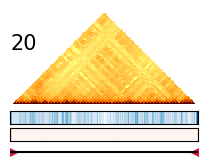

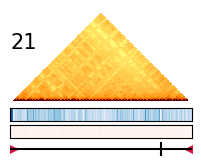

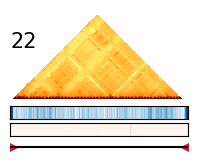

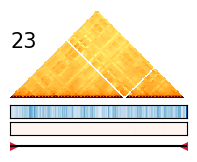

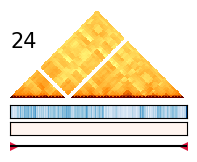

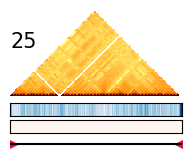

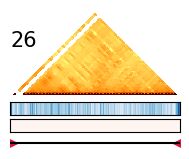

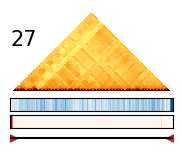

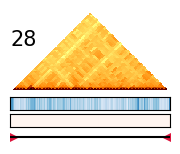

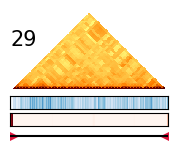

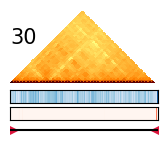

In [17]:
for chrom in np.arange(15,31):

    # chrom size in Mb
    chromSize = get_chrom_size(clr,'scaffold_'+str(chrom))
    
    # telomere data
    
    # ## uncomment these for raw (CCTAA)_2 density
    # idx = df_telo_plus[0]=='scaffold_'+str(chrom)
    # x_telo = np.concatenate((df_telo_plus[1][idx].to_numpy(),np.array(df_telo_plus[2][idx].to_numpy()[[-1]])))
    # y_telo_plus=df_telo_plus[6][idx].to_numpy()
    # y_telo_minus=df_telo_minus[6][idx].to_numpy()
    # y_telo = y_telo_plus + y_telo_minus
    
    idx = df_telo_terminus[0]=='scaffold_'+str(chrom)
    x_telo_terminus = df_telo_terminus[1][idx].to_numpy()
    
    # simple repeat and satellite data
    idx = df_srp_sat[0]=='scaffold_'+str(chrom)
    x_srp_sat = np.concatenate((df_srp_sat[1][idx].to_numpy(),np.array(df_srp_sat[2][idx].to_numpy()[[-1]])))
    y_srp_sat=df_srp_sat[6][idx].to_numpy()
    
    # TE data
    idx = df_te[0]=='scaffold_'+str(chrom)
    x_te = np.concatenate((df_te[1][idx].to_numpy(),np.array(df_te[2][idx].to_numpy()[[-1]])))
    y_te=df_te[6][idx].to_numpy()
    
    # gap data
    idx = df_gap[0]=='scaffold_'+str(chrom)
    x_gap = (df_gap[1][idx].to_numpy() + df_gap[2][idx].to_numpy())/2
    
    # Hi-C data
    A = get_contact_matrix_per_chrom(clr,chrom)
    
    C = np.tril(A)
    # Mask the upper triangle.
    C = np.ma.masked_array(C, C == 0)
    N = A.shape[0]
    
    # Transformation matrix for rotating the heatmap.
    T = np.array([(y, x) for x in range(N, -1, -1) for y in range(N + 1)])
    t = np.array([[0.5, -1], [0.5, 1]])
    T = np.dot(T, t)

    δL_v = 0.25 # intended height for each horizontal panel below the Hi-C heatmap
    δL_h_ratio = 1.5
    dim_v = 4
    
    f, axes = plt.subplots(dim_v,1,
        figsize=(chromSize/δL_h_ratio * δL_v,δL_v * (dim_v-1+chromSize/(2*δL_h_ratio))),
        gridspec_kw={'height_ratios': [chromSize/(1.25*δL_h_ratio)]+[1]*(dim_v-1)}
                          )
    # This MUST be before the call to pl.pcolormesh() to align properly.
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    
    
    # Plot the heatmap triangle.
    X = T[:, 0].reshape(N + 1, N + 1)
    Y = T[:, 1].reshape(N + 1, N + 1)
    cmap='afmhot_r'
    
    # norm = LogNorm(vmax=0.1,vmin=1e-4) # for single chrom
    norm = LogNorm(vmax=1,vmin=1e-3) # for multiple chrom
    
    axes[0].pcolormesh(X, Y, np.flipud(C), cmap=cmap, norm=norm)
    axes[0].set_ylim(0,N)
    axes[0].set_xlim(0,N)
    axes[0].set_aspect(0.5)
    axes[0].set_frame_on(False)

    if chrom==1:
        axes[0].annotate(str('Z'),(0,N*0.75),size=15,va='top')
    elif chrom==3 or chrom==14:
        axes[0].annotate(str(chrom),(0,N*0.5),size=15,va='top')
    else:
        axes[0].annotate(str(chrom),(0,N*0.75),size=15,va='top')
    
    
    ### Plot TE density
    
    Z = np.matrix(y_te)
    x = x_te/1e6
    y = np.array([1,2])
    X,Y = np.meshgrid(x,y)
    
    axes[1].pcolormesh(X,Y,Z,vmax=1,vmin=0,rasterized=True,cmap='Blues')
    
    # axes[1].set_xlim(-0.1,chromSize+0.1)
    # axes[1].set_ylim(-0.1,1)
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    axes[1].set_frame_on(True)
    
    ### Plot simple repeat and satellite density
    
    Z = np.matrix(y_srp_sat)
    x = x_srp_sat/1e6
    y = np.array([1,2])
    X,Y = np.meshgrid(x,y)
    
    axes[2].pcolormesh(X,Y,Z,vmax=1,vmin=0,rasterized=True,cmap='Reds')
    
    # axes[2].set_xlim(-0.1,chromSize+0.1)
    # axes[2].set_ylim(-0.1,1)
    axes[2].set_xticks([])
    axes[2].set_yticks([])
    axes[2].set_frame_on(True)
    
    
    # Chromosome coordinate
    
    # Z = np.matrix(y_srp)
    # x = x_srp/1e6
    # y = np.array([1,2])
    # X,Y = np.meshgrid(x,y)
    
    axes[3].hlines([0],0,chromSize,color='black')
    
    # draw gaps
    axes[3].scatter(x_gap/1e6,np.repeat([0],x_gap.shape[0]),marker='|',c='black',s=100)
    
    # draw telomeres
    if x_telo_terminus.shape[0] > 0:
        for i in x_telo_terminus:
            if i == 'left':
                axes[3].scatter([0],[0],marker='>',c='crimson',s=100)
            elif i == 'right':
                axes[3].scatter([chromSize],[0],marker='<',c='crimson',s=100)
        
    axes[3].set_xlim(0,chromSize)
    
    # axes[2].set_xlim(-0.1,chromSize+0.1)
    # axes[2].set_ylim(-0.1,1)
    axes[-1].set_xticks([])
    axes[-1].set_yticks([])
    axes[-1].set_frame_on(False)
    
    # # axes[2].imshow(x_telo/1e6,(np.array(y_telo_plus)).reshape(y_telo_plus.shape[0],1),color='gray')
    # axes[2].plot(x_telo[1:]/1e6,y_telo,color='coral')
    # axes[2].set_xlim(-0.1,chromSize+0.1)
    # axes[2].set_ylim(-0.1,1)
    # axes[2].set_xticks([])
    # axes[2].set_yticks([])
    # axes[2].set_frame_on(False)
    
    plt.subplots_adjust(wspace=0, 
                        hspace=δL_v/2)

    f.savefig('/home/tx84/Research/2024_LepChromosomes/Papilio_bianor_assembly/AssemblySummaryPlots_CuratedRepeatLib/HiC_TE_TR.scaffold_'+str(chrom)+'.pdf',
         transparent=True,
        bbox_inches='tight'
         )


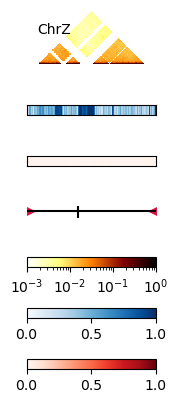

In [11]:
## For drawing colorbars

chrom=1

# chrom size in Mb
# chromSize = get_chrom_size(clr,'scaffold_'+str(chrom))
chromSize=10

# telomere data

# ## uncomment these for raw (CCTAA)_2 density
# idx = df_telo_plus[0]=='scaffold_'+str(chrom)
# x_telo = np.concatenate((df_telo_plus[1][idx].to_numpy(),np.array(df_telo_plus[2][idx].to_numpy()[[-1]])))
# y_telo_plus=df_telo_plus[6][idx].to_numpy()
# y_telo_minus=df_telo_minus[6][idx].to_numpy()
# y_telo = y_telo_plus + y_telo_minus

idx = df_telo_terminus[0]=='scaffold_'+str(chrom)
x_telo_terminus = df_telo_terminus[1][idx].to_numpy()

# simple repeat and satellite data
idx = df_srp_sat[0]=='scaffold_'+str(chrom)
x_srp_sat = np.concatenate((df_srp_sat[1][idx].to_numpy(),np.array(df_srp_sat[2][idx].to_numpy()[[-1]])))
y_srp_sat=df_srp_sat[6][idx].to_numpy()

# TE data
idx = df_te[0]=='scaffold_'+str(chrom)
x_te = np.concatenate((df_te[1][idx].to_numpy(),np.array(df_te[2][idx].to_numpy()[[-1]])))
y_te=df_te[6][idx].to_numpy()

# gap data
idx = df_gap[0]=='scaffold_'+str(chrom)
x_gap = (df_gap[1][idx].to_numpy() + df_gap[2][idx].to_numpy())/2

# Hi-C data
A = get_contact_matrix_per_chrom(clr,chrom)

C = np.tril(A)
# Mask the upper triangle.
C = np.ma.masked_array(C, C == 0)
N = A.shape[0]

# Transformation matrix for rotating the heatmap.
T = np.array([(y, x) for x in range(N, -1, -1) for y in range(N + 1)])
t = np.array([[0.5, -1], [0.5, 1]])
T = np.dot(T, t)

δL_v = 0.25 # intended height for each horizontal panel below the Hi-C heatmap
δL_h_ratio = 1.5
dim_v = 7

f, axes = plt.subplots(dim_v,1,
    figsize=(chromSize/δL_h_ratio * δL_v,2*δL_v * (dim_v-1+chromSize/(2*δL_h_ratio))),
    gridspec_kw={'height_ratios': [chromSize/(1.25*δL_h_ratio)]+[1]*(dim_v-1)}
                      )
# This MUST be before the call to pl.pcolormesh() to align properly.
axes[0].set_xticks([])
axes[0].set_yticks([])


# Plot the heatmap triangle.
X = T[:, 0].reshape(N + 1, N + 1)
Y = T[:, 1].reshape(N + 1, N + 1)
cmap='afmhot_r'

# norm = LogNorm(vmax=0.1,vmin=1e-4) # for single chrom
norm = LogNorm(vmax=1,vmin=1e-3) # for multiple chrom

ax0 = axes[0].pcolormesh(X, Y, np.flipud(C), cmap=cmap, norm=norm)
axes[0].set_ylim(0,N)
axes[0].set_xlim(0,N)
axes[0].set_aspect(0.5)
axes[0].set_frame_on(False)

# axes[0].annotate("Chr"+str(chrom),(0,N*0.75),va='top')
axes[0].annotate("Chr"+str('Z'),(0,N*0.75),va='top')


### Plot TE density

Z = np.matrix(y_te)
x = x_te/1e6
y = np.array([1,2])
X,Y = np.meshgrid(x,y)

ax1 = axes[1].pcolormesh(X,Y,Z,vmax=1,vmin=0,rasterized=True,cmap='Blues')

# axes[1].set_xlim(-0.1,chromSize+0.1)
# axes[1].set_ylim(-0.1,1)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].set_frame_on(True)

### Plot simple repeat and satellite density

Z = np.matrix(y_srp_sat)
x = x_srp_sat/1e6
y = np.array([1,2])
X,Y = np.meshgrid(x,y)

ax2 = axes[2].pcolormesh(X,Y,Z,vmax=1,vmin=0,rasterized=True,cmap='Reds')

# axes[2].set_xlim(-0.1,chromSize+0.1)
# axes[2].set_ylim(-0.1,1)
axes[2].set_xticks([])
axes[2].set_yticks([])
axes[2].set_frame_on(True)


# Chromosome coordinate

# Z = np.matrix(y_srp)
# x = x_srp/1e6
# y = np.array([1,2])
# X,Y = np.meshgrid(x,y)

axes[3].hlines([0],0,chromSize,color='black')

# draw gaps
axes[3].scatter(4,np.repeat([0],1),marker='|',c='black',s=100)

# draw telomeres
if x_telo_terminus.shape[0] > 0:
    for i in x_telo_terminus:
        if i == 'left':
            axes[3].scatter([0],[0],marker='>',c='crimson',s=100)
        elif i == 'right':
            axes[3].scatter([chromSize],[0],marker='<',c='crimson',s=100)
    
axes[3].set_xlim(0,chromSize)

# axes[2].set_xlim(-0.1,chromSize+0.1)
# axes[2].set_ylim(-0.1,1)
axes[3].set_xticks([])
axes[3].set_yticks([])
axes[3].set_frame_on(False)

# # axes[2].imshow(x_telo/1e6,(np.array(y_telo_plus)).reshape(y_telo_plus.shape[0],1),color='gray')
# axes[2].plot(x_telo[1:]/1e6,y_telo,color='coral')
# axes[2].set_xlim(-0.1,chromSize+0.1)
# axes[2].set_ylim(-0.1,1)
# axes[2].set_xticks([])
# axes[2].set_yticks([])
# axes[2].set_frame_on(False)

f.colorbar(ax0,cax=axes[4],location='bottom')
f.colorbar(ax1,cax=axes[5],location='bottom',ticks=[0,0.5,1])
f.colorbar(ax2,cax=axes[6],location='bottom',ticks=[0,0.5,1])

plt.subplots_adjust(wspace=0, 
                    hspace=δL_v*10)



In [76]:
f.savefig('/home/tx84/Research/2024_LepChromosomes/Papilio_bianor_assembly/AssemblySummaryPlots/HiC_TE_TR.legend.pdf',
         transparent=True,
        bbox_inches='tight'
         )


### 2.2. Hi-C spectral purity and double COs

In [8]:
df_co = pd.read_csv("/home/tx84/Research/2024_LepChromosomes/Papilio_bianor_assembly/InferredCOFreq/CO_freq.csv")
freq_2co = df_co['Freq2CO'].to_numpy()

In [9]:
clr = cooler.Cooler(f'{mcool_file}::resolutions/1000000')

### to print chromosomes and binsize for this cooler
# print(f'chromosomes: {clr.chromnames}, binsize: {clr.binsize}')

### to make a list of chromosome start/ends in bins:
chromstarts = []
chromends = []
for i in clr.chromnames:
    # print(f'{i} : {clr.extent(i)}')
    chromstarts.append(clr.extent(i)[0])
    chromends.append(clr.extent(i)[1])

In [10]:
purity=[]
C_matrix=[]
C_matrix_raw=[]
C_matrix_spectrum=[]

for chrom in np.arange(1,31,1):

# chrom = 17

# chrom=7
# def plot_save_contact_corrcoef(chrom):

    A = clr.matrix(balance=True)[chromstarts[chrom-1]:chromends[chrom-1],chromstarts[chrom-1]:chromends[chrom-1]]
    idx_nan = np.where(np.isnan(np.diagonal(A)))[0]
    idx_not_nan = np.where(np.logical_not(np.isnan(np.diagonal(A))))[0]
    B = A[np.matrix(idx_not_nan).transpose(),idx_not_nan]
    C = (np.array(pd.DataFrame(np.log(B)).corr()))/B.shape[0]

    s = np.linalg.eigvals(C)
    purity.append((np.sum((s)**2)-(1/B.shape[0]))/(1-(1/B.shape[0])))
    C_matrix.append(C)
    C_matrix_spectrum.append(s)
    C_matrix_raw.append(C * B.shape[0])

In [11]:
lr_out = sp.stats.linregress(purity[1:31],freq_2co[1:31])
pval=lr_out.pvalue

(-0.05, 0.65)

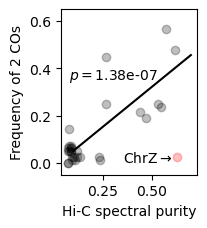

In [40]:
f, ax=plt.subplots(figsize=(1.75,2.15))

ax.scatter(purity[1:31],freq_2co[1:31],
           c='black',
           alpha=0.25,
          )

ax.scatter(purity[0],freq_2co[0],
           c='red',
           alpha=0.25,
          )

x=np.array([0.1,0.7])
plt.plot(x, lr_out.intercept + lr_out.slope*x, 'black',)

ax.annotate("ChrZ"+r"$\rightarrow$",xy=(purity[0]-0.275,freq_2co[0]),
           c='black',
        horizontalalignment='left',
            verticalalignment='center',
          )

ax.annotate(r"$p=$"+format(lr_out.pvalue,".2e"),xy=(0.08,0.37),
           c='black',
        horizontalalignment='left',
            verticalalignment='center',
          )
ax.set_xlabel('Hi-C spectral purity')
ax.set_ylabel('Frequency of 2 COs')
ax.set_ylim(-0.05,0.65)

In [41]:
dir_out="/home/tx84/Research/2024_LepChromosomes/Papilio_bianor_assembly/HiCSpectralPurity"

f.savefig(dir_out+"/Purity_vs_2COfreq.png",dpi=300,bbox_inches='tight')
f.savefig(dir_out+"/Purity_vs_2COfreq.pdf",bbox_inches='tight')

Text(3, 0.7, 'Low\npurity')

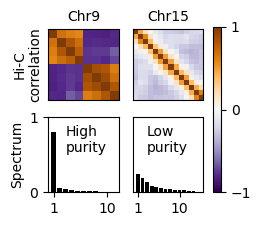

In [11]:
## generate example plots to explain spectral purity
## chrom 9, 6, 15

f, axes = plt.subplots(2,2,
    figsize=(2.5,2.15),
                      )

for i in range(2):
    axes[0,i].set_xticks([])
    axes[0,i].set_yticks([])

chrom=9
axes[0,0].imshow(C_matrix_raw[chrom-1],cmap='PuOr_r',vmin=-1,vmax=1,
                )
axes[0,0].set_title("Chr"+str(chrom),fontsize=10)

# chrom=6
# axes[0,1].imshow(C_matrix_raw[chrom-1],cmap='PuOr_r',vmin=-1,vmax=1,
#                 )
# axes[0,1].set_title("Chr"+str(chrom),fontsize=10)

chrom=15
im = axes[0,1].imshow(C_matrix_raw[chrom-1],cmap='PuOr_r',vmin=-1,vmax=1,
                     )
axes[0,1].set_title("Chr"+str(chrom),fontsize=10)

cbar=f.colorbar(im, ax=axes.ravel().tolist(),ticks=[-1, 0, 1],)
# cbar.ax.set_yticks([-1,0,1],['-1','0','1'])

y=np.sort(C_matrix_spectrum[4])[::-1]
axes[1,0].bar(np.arange(1,y.shape[0]+1),y,
              color='black'
       )
axes[1,0].set_ylim(0,1)
# axes[1,0].set_xlim(0,10)
# axes[1,0].set_aspect(10)
axes[1,0].set_yticks([0,1])
axes[1,0].set_xticks([1,10])

# y=np.sort(C_matrix_spectrum[5])[::-1]
# axes[1,1].bar(np.arange(1,y.shape[0]+1),y,
#               color='black'
#        )
# axes[1,1].set_ylim(0,1)
# axes[1,1].set_xlim(0,10)
# axes[1,1].set_aspect(10)
# axes[1,1].set_yticks([])

y=np.sort(C_matrix_spectrum[14])[::-1]
axes[1,1].bar(np.arange(1,y.shape[0]+1),y,
              color='black'
       )
axes[1,1].set_ylim(0,1)
# axes[1,1].set_xlim(0,10)
# axes[1,1].set_aspect(10)
axes[1,1].set_yticks([])
axes[1,1].set_xticks([1,10])

axes[0,0].set_ylabel("Hi-C\ncorrelation")
axes[1,0].set_ylabel("Spectrum")

axes[1,0].annotate("High\npurity",xy=(3,0.7),
           c='black',
        horizontalalignment='left',
            verticalalignment='center',
          )
# axes[1,1].annotate("Intermediate",xy=(1,0.7),
#            c='black',
#         horizontalalignment='left',
#             verticalalignment='center',
#           )
axes[1,1].annotate("Low\npurity",xy=(3,0.7),
           c='black',
        horizontalalignment='left',
            verticalalignment='center',
          )




In [12]:
dir_out="/home/tx84/Research/2024_LepChromosomes/Papilio_bianor_assembly/HiCSpectralPurity"

f.savefig(dir_out+"/Spectral_purity_example.png",dpi=300,bbox_inches='tight')
f.savefig(dir_out+"/Spectral_purity_example.pdf",bbox_inches='tight')

### 2.3. Hi-C contact properties for different chromosomes

#### Short-range contact: $P(s)$ curves

In [152]:
clr = cooler.Cooler(f'{mcool_file}::resolutions/1000')

### to print chromosomes and binsize for this cooler
# print(f'chromosomes: {clr.chromnames}, binsize: {clr.binsize}')

### to make a list of chromosome start/ends in bins:
chromstarts = []
chromends = []
for i in clr.chromnames:
    # print(f'{i} : {clr.extent(i)}')
    chromstarts.append(clr.extent(i)[0])
    chromends.append(clr.extent(i)[1])

In [153]:
# f,ax=plt.subplots(1,1)
# ax.plot([4.5,5.5],np.array([-1,-2])+0.025)

chromList1=np.array([1,2,4,5,6,7,8,9,10,11,12,13])
chromList2=np.array([3,14])
chromList3=np.arange(15,31,1)

log_s_TErich=[]
log_Ps_TErich=[]
log_s_TEscarce=[]
log_Ps_TEscarce=[]

for chrom in chromList1:

    te_l = dict_TE_block['chr'+str(chrom)+',5']*1e6
    te_r = dict_TE_block['chr'+str(chrom)+',3']*1e6

    idx_l = map_interval_to_pixels(clr,'scaffold_'+str(chrom),0,te_l)
    idx_r = map_interval_to_pixels(clr,'scaffold_'+str(chrom),te_r,get_chrom_size(clr,'scaffold_'+str(chrom))*1e6)
    
    A_l = clr.matrix(balance=True)[idx_l[0]:(idx_l[-1]+1),idx_l[0]:(idx_l[-1]+1)]
    A_r = clr.matrix(balance=True)[idx_r[0]:(idx_r[-1]+1),idx_r[0]:(idx_r[-1]+1)]
    # A_l_by_r = clr.matrix(balance=True)[idx_l[0]:(idx_l[-1]+1),idx_r[0]:(idx_r[-1]+1)]

    Ps_l = np.array(drop_nan_from_end(get_striped_mean(A_l)))
    Ps_r = np.array(drop_nan_from_end(get_striped_mean(A_r)))
    
    s_l = np.arange(0,Ps_l.shape[0]) * clr.binsize
    s_r = np.arange(0,Ps_r.shape[0]) * clr.binsize

    log_s_l,log_P_l = log_smoothing(Ps_l,s_l,40)
    log_s_r,log_P_r = log_smoothing(Ps_r,s_r,40)
    log_s_l = np.array(log_s_l)
    log_P_l = np.array(log_P_l)
    log_s_r = np.array(log_s_r)
    log_P_r = np.array(log_P_r)
        
    # ax.loglog(10**log_s_l,10**log_P_l,color='red',alpha=0.01)
    # ax.loglog(10**log_s_r,10**log_P_r,color='red',alpha=0.01)
    # ax.set_aspect(1)

    log_s_TErich.append(log_s_l)
    log_Ps_TErich.append(log_P_l)
    log_s_TErich.append(log_s_r)
    log_Ps_TErich.append(log_P_r)

## We ignore chrom 3 and chrom 14 since they are TE rich but not bipartite due to incomplete assembly.
# for chrom in chromList2:

#     te_l = dict_TE_block['chr'+str(chrom)+',5']*1e6
#     te_r = dict_TE_block['chr'+str(chrom)+',3']*1e6

#     if chrom==3:
#         idx = map_interval_to_pixels(clr,'scaffold_'+str(chrom),te_r,get_chrom_size(clr,'scaffold_'+str(chrom))*1e6)
#     else:  
#         idx = map_interval_to_pixels(clr,'scaffold_'+str(chrom),0,te_l)
    
#     A = clr.matrix(balance=True)[idx[0]:(idx[-1]+1),idx[0]:(idx[-1]+1)]

#     Ps = np.array(drop_nan_from_end(get_striped_mean(A)))
    
#     s = np.arange(0,Ps.shape[0]) * clr.binsize

#     log_s,log_P = log_smoothing(Ps,s,40)
#     log_s = np.array(log_s)
#     log_P = np.array(log_P)
        
#     # ax.loglog(10**log_s,10**log_P,color='red',alpha=0.01)
#     # ax.set_aspect(1)

#     log_s_TErich.append(log_s)
#     log_Ps_TErich.append(log_P)

for chrom in chromList3:

    idx = map_interval_to_pixels(clr,'scaffold_'+str(chrom),0,get_chrom_size(clr,'scaffold_'+str(chrom))*1e6)
    
    A = clr.matrix(balance=True)[idx[0]:(idx[-1]+1),idx[0]:(idx[-1]+1)]

    Ps = np.array(drop_nan_from_end(get_striped_mean(A)))
    
    s = np.arange(0,Ps.shape[0]) * clr.binsize

    log_s,log_P = log_smoothing(Ps,s,40)
    log_s = np.array(log_s)
    log_P = np.array(log_P)
        
    # ax.loglog(10**log_s,10**log_P,color='blue',alpha=0.01)
    # ax.set_aspect(1)

    log_s_TEscarce.append(log_s)
    log_Ps_TEscarce.append(log_P)

#     A = clr.matrix(balance=True)[chromstarts[chrom-1]:chromends[chrom-1],chromstarts[chrom-1]:chromends[chrom-1]]
#     idx_nan = np.where(np.isnan(np.diagonal(A)))[0]
#     idx_not_nan = np.where(np.logical_not(np.isnan(np.diagonal(A))))[0]
    
#     L = A.shape[0]
#     ΔL = np.arange(0,L)
    
#     A_diag_mean = []
#     for δL in ΔL: 
#         A_diag = np.diagonal(A,offset=δL)
#         A_diag_mean.append(A_diag[np.logical_not(np.isnan(A_diag))].mean())
    
#     ax.plot(np.log10(ΔL*1000),np.log10(A_diag_mean),color='blue',alpha=0.1)
#     ax.set_aspect(1)

# # ax.set_xlim(np.log10(1e5),np.log10(1e7))
# # ax.set_ylim(-4,-2)

# ax.set_xlim(np.log10(1e4),7)
# ax.set_ylim(-5,-2)

# ax.plot([4,6],[-2.8,-2.8-2*(3/3.5)])

# ax.grid(visible=True)

/tmp/ipykernel_750156/1897756668.py:50: RuntimeWarning: Mean of empty slice.
  log_s.append((np.log10(s[idx])).mean())
/home/tx84/miniconda3/envs/EnvPy3.12/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_750156/1897756668.py:51: RuntimeWarning: Mean of empty slice.
  log_P.append((np.log10(Ps[idx])).mean())
/tmp/ipykernel_750156/1897756668.py:51: RuntimeWarning: divide by zero encountered in log10
  log_P.append((np.log10(Ps[idx])).mean())


In [154]:
log_s_TErich = np.matrix(log_s_TErich)
log_Ps_TErich = np.matrix(log_Ps_TErich)
log_s_TEscarce = np.matrix(log_s_TEscarce)
log_Ps_TEscarce = np.matrix(log_Ps_TEscarce)

log_s_TErich_final = np.array([])
log_Ps_TErich_final = np.array([])

for i in np.arange(0,log_s_TErich.shape[1]):

    idx = np.array(np.logical_not(np.isnan(log_s_TErich[:,i]))).flatten()

    if idx.sum() > 0:
        log_s_TErich_final = np.append(log_s_TErich_final,log_s_TErich[idx,i].mean())
        log_Ps_slice = log_Ps_TErich[idx,i]
        log_Ps_slice = log_Ps_slice[np.isfinite(log_Ps_slice)]
        log_Ps_TErich_final = np.append(log_Ps_TErich_final,log_Ps_slice.mean())
    else:
        continue

log_s_TEscarce_final = np.array([])
log_Ps_TEscarce_final = np.array([])

for i in np.arange(0,log_s_TEscarce.shape[1]):

    idx = np.array(np.logical_not(np.isnan(log_s_TEscarce[:,i]))).flatten()

    if idx.sum() > 0:
        log_s_TEscarce_final = np.append(log_s_TEscarce_final,log_s_TEscarce[idx,i].mean())
        log_Ps_TEscarce_final = np.append(log_Ps_TEscarce_final,log_Ps_TEscarce[idx,i].mean())
    else:
        continue

Ps_TErich_deri_x = (log_s_TErich_final[1:]+log_s_TErich_final[0:-1])/2
Ps_TErich_deri_y =  (log_Ps_TErich_final[1:]-log_Ps_TErich_final[0:-1])/(log_s_TErich_final[1:]-log_s_TErich_final[0:-1])
Ps_TEscarce_deri_x = (log_s_TEscarce_final[1:]+log_s_TEscarce_final[0:-1])/2
Ps_TEscarce_deri_y =  (log_Ps_TEscarce_final[1:]-log_Ps_TEscarce_final[0:-1])/(log_s_TEscarce_final[1:]-log_s_TEscarce_final[0:-1])

/home/tx84/miniconda3/envs/EnvPy3.12/lib/python3.12/site-packages/numpy/matrixlib/defmatrix.py:446: RuntimeWarning: Mean of empty slice.
  return N.ndarray.mean(self, axis, dtype, out, keepdims=True)._collapse(axis)
/home/tx84/miniconda3/envs/EnvPy3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


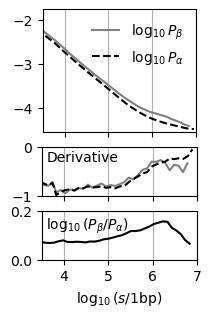

In [161]:
fig,ax=plt.subplots(3,1,
                    figsize=(2,3.25),
                    gridspec_kw={'height_ratios': [0.75,0.3,0.3]}
                   )

ax[0].plot(log_s_TErich_final,log_Ps_TErich_final,
        c='gray',
        label=r"$\log_{10} P_{\beta}$",
        )
ax[0].plot(log_s_TEscarce_final,log_Ps_TEscarce_final,
        label=r"$\log_{10} P_{\alpha}$",
        linestyle='--',
        c='black')

ax[0].set_xlim(3.5,7)
ax[0].set_ylim(-4.55,-1.75)
ax[0].set_aspect(1)
ax[0].set_xticks([4,5,6,7],['','','',''])
ax[0].legend(loc='upper right',frameon=False)
ax[0].grid(axis='x')


ax[1].plot(Ps_TErich_deri_x,Ps_TErich_deri_y,c='gray')
ax[1].plot(Ps_TEscarce_deri_x,Ps_TEscarce_deri_y,c='black',linestyle='--')
ax[1].set_xlim(3.5,7)
ax[1].set_ylim(-1,0)
ax[1].set_xticks([4,5,6,7],['','','',''])
ax[1].annotate("Derivative",(3.6,-0.3))
ax[1].grid(axis='x')

ax[2].plot(log_s_TErich_final,(log_Ps_TErich_final-log_Ps_TEscarce_final),
           c='black',
          )
ax[2].set_xlim(3.5,7)
ax[2].set_ylim(0,0.2)
ax[2].set_xticks([4,5,6,7])
ax[2].set_xlabel(r"$\log_{10}(s/1\text{bp})$")
ax[2].annotate(r"$\log_{10}(P_{\beta}/P_{\alpha})$",(3.6,0.125))
ax[2].grid(axis='x')

In [162]:
dir_out='/home/tx84/Research/2024_LepChromosomes/Papilio_bianor_assembly/Ps_curves'
fig.savefig(dir_out+'/Ps_curves_P0P1.png',dpi=300,bbox_inches='tight')
fig.savefig(dir_out+'/Ps_curves_P0P1.pdf',bbox_inches='tight')

#### Long-range contact: end-end, trans

In [18]:
clr = cooler.Cooler(f'{mcool_file}::resolutions/1000')

### to print chromosomes and binsize for this cooler
# print(f'chromosomes: {clr.chromnames}, binsize: {clr.binsize}')

### to make a list of chromosome start/ends in bins:
chromstarts = []
chromends = []
for i in clr.chromnames:
    # print(f'{i} : {clr.extent(i)}')
    chromstarts.append(clr.extent(i)[0])
    chromends.append(clr.extent(i)[1])

In [19]:
chromList1=np.array([1,2,4,5,6,7,8,9,10,11,12,13])
chromList2=np.array([3,14])
chromList3=np.arange(15,31,1)

In [20]:
end_end_bipartite = np.array([])
end_end_canonical = np.array([])

for chrom in chromList1:

    idx_l = map_interval_to_pixels(clr,'scaffold_'+str(chrom),0,2e6)
    idx_r = map_interval_to_pixels(clr,'scaffold_'+str(chrom),get_chrom_size(clr,'scaffold_'+str(chrom))*1e6 - 2e6,get_chrom_size(clr,'scaffold_'+str(chrom))*1e6)
    
    A_l_by_r = clr.matrix(balance=True)[idx_l[0]:(idx_l[-1]+1),idx_r[0]:(idx_r[-1]+1)].flatten()
    
    end_end_bipartite = np.append(end_end_bipartite,A_l_by_r[np.logical_not(np.isnan(A_l_by_r))].mean())

for chrom in chromList3:

    idx_l = map_interval_to_pixels(clr,'scaffold_'+str(chrom),0,2e6)
    idx_r = map_interval_to_pixels(clr,'scaffold_'+str(chrom),get_chrom_size(clr,'scaffold_'+str(chrom))*1e6 - 2e6,get_chrom_size(clr,'scaffold_'+str(chrom))*1e6)
    
    A_l_by_r = clr.matrix(balance=True)[idx_l[0]:(idx_l[-1]+1),idx_r[0]:(idx_r[-1]+1)].flatten()
    
    end_end_canonical = np.append(end_end_canonical,A_l_by_r[np.logical_not(np.isnan(A_l_by_r))].mean())

In [21]:
trans_bipartite_bipartite = np.array([])
trans_canonical_canonical = np.array([])
trans_bipartite_canonical = np.array([])

for chrom1,chrom2 in tqdm.tqdm(itertools.product(chromList1,chromList3)):
    
    idx_l = map_interval_to_pixels(clr,'scaffold_'+str(chrom1),0,get_chrom_size(clr,'scaffold_'+str(chrom1))*1e6)
    idx_r = map_interval_to_pixels(clr,'scaffold_'+str(chrom2),0,get_chrom_size(clr,'scaffold_'+str(chrom2))*1e6)
    
    A_l_by_r = clr.matrix(balance=True)[idx_l[0]:(idx_l[-1]+1),idx_r[0]:(idx_r[-1]+1)].flatten()

    trans_bipartite_canonical = np.append(trans_bipartite_canonical,A_l_by_r[np.logical_not(np.isnan(A_l_by_r))].mean())

for chrom1,chrom2 in tqdm.tqdm(itertools.combinations(chromList1,2)):

    idx_l = map_interval_to_pixels(clr,'scaffold_'+str(chrom1),0,get_chrom_size(clr,'scaffold_'+str(chrom1))*1e6)
    idx_r = map_interval_to_pixels(clr,'scaffold_'+str(chrom2),0,get_chrom_size(clr,'scaffold_'+str(chrom2))*1e6)
    
    A_l_by_r = clr.matrix(balance=True)[idx_l[0]:(idx_l[-1]+1),idx_r[0]:(idx_r[-1]+1)].flatten()
    
    trans_bipartite_bipartite = np.append(trans_bipartite_bipartite,A_l_by_r[np.logical_not(np.isnan(A_l_by_r))].mean())

for chrom1,chrom2 in tqdm.tqdm(itertools.combinations(chromList3,2)):

    idx_l = map_interval_to_pixels(clr,'scaffold_'+str(chrom1),0,get_chrom_size(clr,'scaffold_'+str(chrom1))*1e6)
    idx_r = map_interval_to_pixels(clr,'scaffold_'+str(chrom2),0,get_chrom_size(clr,'scaffold_'+str(chrom2))*1e6)
    
    A_l_by_r = clr.matrix(balance=True)[idx_l[0]:(idx_l[-1]+1),idx_r[0]:(idx_r[-1]+1)].flatten()
    
    trans_canonical_canonical = np.append(trans_canonical_canonical,A_l_by_r[np.logical_not(np.isnan(A_l_by_r))].mean())


192it [07:05,  2.21s/it]
66it [02:18,  2.10s/it]
120it [04:21,  2.18s/it]


In [22]:
test1 = sp.stats.ttest_ind(np.log10(end_end_canonical),np.log10(end_end_bipartite),equal_var=False)
p1 = format(test1.pvalue,".1e")
test2 = sp.stats.ttest_ind(np.log10(trans_bipartite_bipartite),np.log10(trans_bipartite_canonical),equal_var=False)
p2 = format(test2.pvalue,".1e")
test3 = sp.stats.ttest_ind(np.log10(trans_bipartite_bipartite),np.log10(trans_canonical_canonical),equal_var=False)
p3 = format(test3.pvalue,".1e")
test4 = sp.stats.ttest_ind(np.log10(trans_bipartite_canonical),np.log10(trans_canonical_canonical),equal_var=False)
p4 = format(test4.pvalue,".1e")

print([p1,p2,p3,p4])

['3.3e-03', '3.5e-13', '1.2e-15', '3.1e-07']


Text(2.2, -4.84, '$p<10^{-14}$')

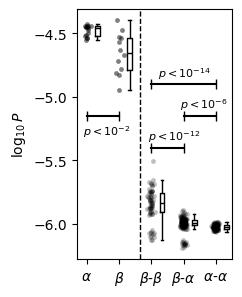

In [61]:
fig,ax=plt.subplots(1,1,
                    figsize=(2,3.25)
                   )

y = np.log10(end_end_canonical)
x = np.random.normal(loc=0.0, scale=0.05, size=y.shape[0])
ax.scatter(x,y,
           c='black',
           alpha=0.5,
           s=12,
           linewidths=0,
          )

ax.boxplot(y,
           positions=[0.33],
           # patch_artist=True, 
           medianprops = dict(color = "black"),
           showfliers=False)


y = np.log10(end_end_bipartite)
x = np.random.normal(loc=1.0, scale=0.05, size=y.shape[0])
ax.scatter(x,y,
           c='black',
           alpha=0.5,
           s=12,
           linewidths=0,
          )

ax.boxplot(y,
           positions=[1.33],
           # patch_artist=True, 
           medianprops = dict(color = "black"),
           showfliers=False)


y = np.log10(trans_bipartite_bipartite)
x = np.random.normal(loc=2.0, scale=0.05, size=y.shape[0])
ax.scatter(x,y,
           c='black',
           alpha=0.25,
           s=12,
           linewidths=0,
          )

ax.boxplot(y,
           positions=[2.33],
           # patch_artist=True, 
           medianprops = dict(color = "black"),
           showfliers=False)

y = np.log10(trans_bipartite_canonical)
x = np.random.normal(loc=3.0, scale=0.05, size=y.shape[0])
ax.scatter(x,y,
           c='black',
           alpha=0.25,
           s=12,
           linewidths=0,
          )

ax.boxplot(y,
           positions=[3.33],
           # patch_artist=True, 
           medianprops = dict(color = "black"),
           showfliers=False)


y = np.log10(trans_canonical_canonical)
x = np.random.normal(loc=4.0, scale=0.05, size=y.shape[0])
ax.scatter(x,y,
           c='black',
           alpha=0.25,
           s=12,
           linewidths=0,
          )

ax.boxplot(y,
           positions=[4.33],
           # patch_artist=True, 
           medianprops = dict(color = "black"),
           showfliers=False)


ax.set_xticks([0,1,2,3,4],[r"$\alpha$",r"$\beta$",r"$\beta$-$\beta$",r"$\beta$-$\alpha$",r"$\alpha$-$\alpha$"],rotation=0)
ax.set_yticks([-4.5,-5,-5.5,-6])
ax.set_ylabel(r"$\log_{10}P$")
ax.set_xlim(-0.3,4.5)
ax.axvline([1.65],c='black',linestyle='dashed',linewidth=1)

# ax.annotate('trans contact', xy=(3, -5.1), xycoords='data', annotation_clip=False,rotation=90)
# ax.annotate('cis contact\nbetween ends', xy=(0.35, -6.15), xycoords='data', annotation_clip=False,rotation=90)

ax.plot([0,1],[-5.15,-5.15],label="",color='black',marker='|',markersize=7)
ax.annotate(r'$p<10^{-2}$',xy=(-0.1,-5.3),xycoords='data', annotation_clip=False,size=8)
# ax.annotate(r'$p<10^{-2}$',xy=(-0.1,-5.3),xycoords='data', annotation_clip=False,size=8)

ax.plot([2,3],[-5.4,-5.4],label="",color='black',marker='|',markersize=7)
ax.plot([3,4],[-5.15,-5.15],label="",color='black',marker='|',markersize=7)
ax.plot([2,4],[-4.9,-4.9],label="",color='black',marker='|',markersize=7)

ax.annotate(r'$p<10^{-12}$',xy=(1.9,-5.34),xycoords='data', annotation_clip=False,size=8)
ax.annotate(r'$p<10^{-6}$',xy=(2.9,-5.09),xycoords='data', annotation_clip=False,size=8)
ax.annotate(r'$p<10^{-14}$',xy=(2.2,-4.84),xycoords='data', annotation_clip=False,size=8)

In [62]:
dir_out='/home/tx84/Research/2024_LepChromosomes/Papilio_bianor_assembly/Ps_curves'
fig.savefig(dir_out+'/LongRangeP.png',dpi=300,bbox_inches='tight')
fig.savefig(dir_out+'/LongRangeP.pdf',bbox_inches='tight')